In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
# Parametres du modele Black-Scholes : dS_t = mu*S_t*dt + sigma*S_t*dW_t
T = 1.0
N = 255
S0 = 100.0
mu = 0.1
sigma = 0.25
r = 0.05   # taux sans risque
K = 110.0  # strike
h = T / N # pas de temps
t = np.linspace(0, T, N + 1)

In [3]:
# Fonction bootstrap (fournie dans l'enonce)
def bootstrap_mean_confidence_interval(data, num_iterations=10000, alpha=0.05):
    n = len(data)
    means = np.zeros(num_iterations)
    for i in range(num_iterations):
        means[i] = np.mean(np.random.choice(data, size=n, replace=True))
    means.sort()
    lower_bound = means[int(num_iterations * (alpha / 2))]
    upper_bound = means[int(num_iterations * (1 - alpha / 2))]
    mean_estimate = np.mean(means)
    return mean_estimate, (lower_bound, upper_bound)

In [4]:
# Prix Black-Scholes analytique (reference)
# Sous la mesure risque-neutre Q* : dS_t = r*S_t*dt + sigma*S_t*dW̃_t
# Prix call europeen : C = S0*N(d1) - K*e^{-rT}*N(d2)
d1 = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2 = d1 - sigma * np.sqrt(T)
BS_price = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
print(f"Prix Black-Scholes analytique : {BS_price:.4f}")

Prix Black-Scholes analytique : 8.0264


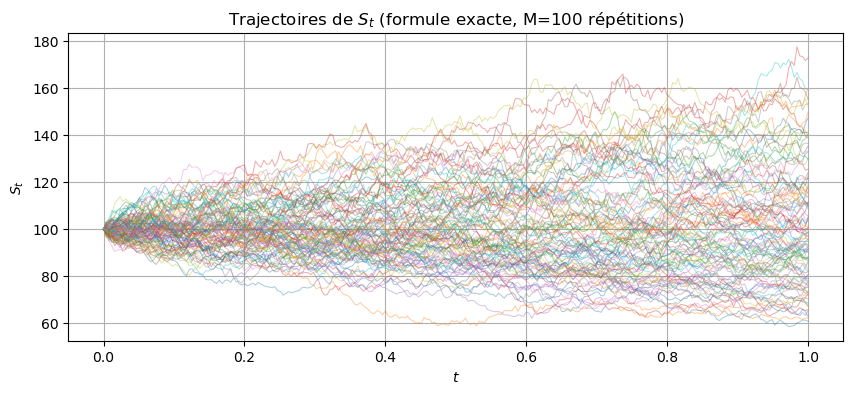

In [5]:
# Question 1 : formule exacte pour S_t
# Sous Q* : S_t = S0 * exp((r - sigma^2/2)*t + sigma*W̃_t)
# On simule W̃_t (mouvement brownien sous Q*) puis on calcule S_t

M = 100

# Increments browniens sous Q*
dW = np.random.normal(0, np.sqrt(h), (M, N))
W  = np.concatenate([np.zeros((M, 1)), np.cumsum(dW, axis=1)], axis=1)  # (M, N+1)

# Solution exacte (formule 4.36 du cours)
S_exact = S0 * np.exp((r - 0.5 * sigma**2) * t + sigma * W)

plt.figure(figsize=(10, 4))
for i in range(M):
    plt.plot(t, S_exact[i], alpha=0.4, linewidth=0.7)
plt.xlabel(r'$t$')
plt.ylabel(r'$S_t$')
plt.title(rf'Trajectoires de $S_t$ (formule exacte, M={M} répétitions)')
plt.grid(True)
plt.show()

In [6]:
# Prix Monte Carlo par la formule (4.31) :
# C_0 = e^{-rT} * E^{Q*}[(S_T - K)_+]  ~  e^{-rT} * (1/M) * sum_m (S_T^m - K)_+

payoffs_exact = np.maximum(S_exact[:, -1] - K, 0)
prix_MC_exact = np.exp(-r * T) * np.mean(payoffs_exact)

_, (lb, ub) = bootstrap_mean_confidence_interval(np.exp(-r * T) * payoffs_exact)

print(f"Prix MC (formule exacte, M={M})  : {prix_MC_exact:.4f}")
print(f"IC bootstrap 95%                 : [{lb:.4f}, {ub:.4f}]")
print(f"Prix Black-Scholes analytique    : {BS_price:.4f}")

Prix MC (formule exacte, M=100)  : 7.4173
IC bootstrap 95%                 : [4.9355, 10.1861]
Prix Black-Scholes analytique    : 8.0264


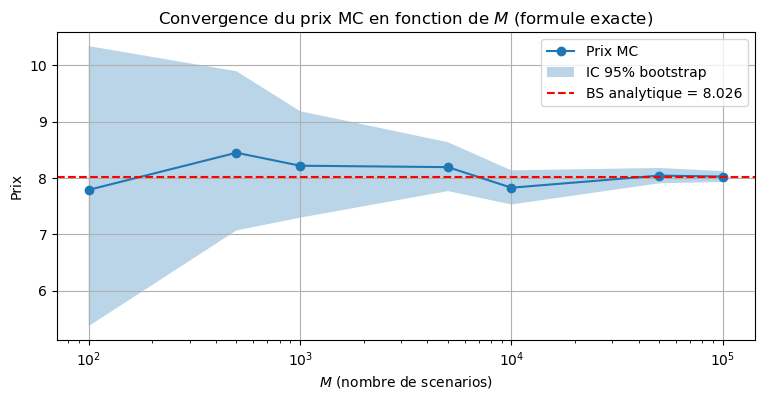

In [7]:
# Convergence du prix MC en fonction de M (formule exacte)
M_values = [100, 500, 1000, 5000, 10000, 50000, 100000]
prix_list = []
lb_list   = []
ub_list   = []

for M_val in M_values:
    dW_m   = np.random.normal(0, np.sqrt(h), (M_val, N))
    W_m    = np.concatenate([np.zeros((M_val, 1)), np.cumsum(dW_m, axis=1)], axis=1)
    S_T_m  = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * W_m[:, -1])
    pf     = np.maximum(S_T_m - K, 0)
    disc_pf = np.exp(-r * T) * pf
    _, (lb_m, ub_m) = bootstrap_mean_confidence_interval(disc_pf)
    prix_list.append(np.mean(disc_pf))
    lb_list.append(lb_m)
    ub_list.append(ub_m)

plt.figure(figsize=(9, 4))
plt.plot(M_values, prix_list, 'o-', label='Prix MC')
plt.fill_between(M_values, lb_list, ub_list, alpha=0.3, label='IC 95% bootstrap') # pour remplir entre les bornes inf/sup de l'IC
plt.axhline(BS_price, color='r', linestyle='--', label=f'BS analytique = {BS_price:.3f}')
plt.xscale('log') # pour avoir l'axe des abscisses en échelle log
plt.xlabel(r'$M$ (nombre de scenarios)')
plt.ylabel('Prix')
plt.title(r'Convergence du prix MC en fonction de $M$ (formule exacte)')
plt.legend()
plt.grid(True)
plt.show()

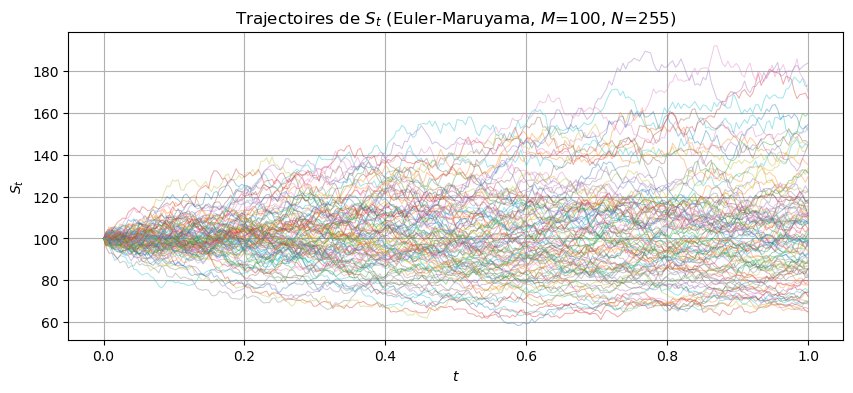

In [8]:
# Question 2 : schema d'Euler-Maruyama pour S_t
# dS_t = r*S_t*dt + sigma*S_t*dW̃_t
# => Y_{n+1} = Y_n + r*Y_n*h + sigma*Y_n*DW_n

M = 100
dW_EM = np.random.normal(0, np.sqrt(h), (M, N))

S_EM = np.zeros((M, N + 1))
S_EM[:, 0] = S0
for n in range(N):
    S_EM[:, n+1] = S_EM[:, n] + r * S_EM[:, n] * h + sigma * S_EM[:, n] * dW_EM[:, n]

plt.figure(figsize=(10, 4))
for i in range(M):
    plt.plot(t, S_EM[i], alpha=0.4, linewidth=0.7)
plt.xlabel(r'$t$')
plt.ylabel(r'$S_t$')
plt.title(rf'Trajectoires de $S_t$ (Euler-Maruyama, $M$={M}, $N$={N})')
plt.grid(True)
plt.show()

In [9]:
# Prix MC avec Euler-Maruyama
payoffs_EM = np.maximum(S_EM[:, -1] - K, 0)
prix_MC_EM = np.exp(-r * T) * np.mean(payoffs_EM)

_, (lb_em, ub_em) = bootstrap_mean_confidence_interval(np.exp(-r * T) * payoffs_EM)

print(f"Prix MC (Euler-Maruyama, M={M}) : {prix_MC_EM:.4f}")
print(f"IC bootstrap 95%               : [{lb_em:.4f}, {ub_em:.4f}]")
print(f"Prix Black-Scholes analytique  : {BS_price:.4f}")

Prix MC (Euler-Maruyama, M=100) : 7.8461
IC bootstrap 95%               : [4.9982, 11.1407]
Prix Black-Scholes analytique  : 8.0264


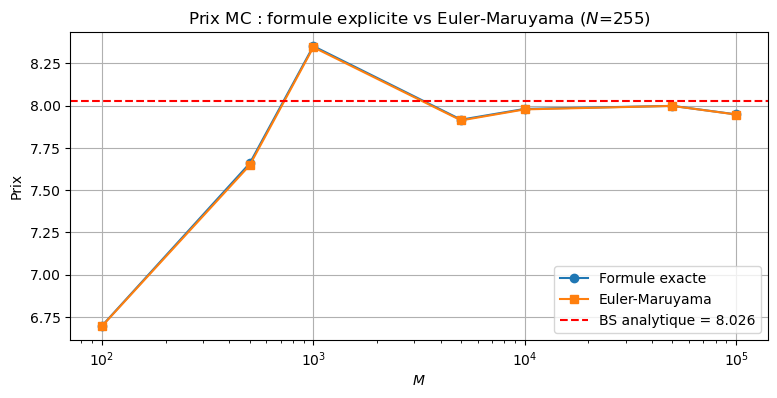

In [10]:
# Comparaison formule exacte vs EM pour M et N fixes
# On fait varier M et on compare les deux estimateurs
M_values = [100, 500, 1000, 5000, 10000, 50000, 100000]

prix_exact_list = []
prix_EM_list    = []

for M_val in M_values:

    dW_c = np.random.normal(0, np.sqrt(h), (M_val, N))

    # Solution exacte
    W_c   = np.concatenate([np.zeros((M_val, 1)), np.cumsum(dW_c, axis=1)], axis=1)
    S_T_ex = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * W_c[:, -1])

    # EM
    S_c = np.zeros((M_val, N + 1)); S_c[:, 0] = S0
    for n in range(N):
        S_c[:, n+1] = S_c[:, n] + r * S_c[:, n] * h + sigma * S_c[:, n] * dW_c[:, n]

    prix_exact_list.append(np.exp(-r * T) * np.mean(np.maximum(S_T_ex - K, 0)))
    prix_EM_list.append(   np.exp(-r * T) * np.mean(np.maximum(S_c[:, -1] - K, 0)))

plt.figure(figsize=(9, 4))
plt.semilogx(M_values, prix_exact_list, 'o-', label='Formule exacte')
plt.semilogx(M_values, prix_EM_list,    's-', label='Euler-Maruyama')
plt.axhline(BS_price, color='r', linestyle='--', label=f'BS analytique = {BS_price:.3f}')
plt.xlabel(r'$M$')
plt.ylabel('Prix')
plt.title(rf'Prix MC : formule explicite vs Euler-Maruyama ($N$={N})')
plt.legend()
plt.grid(True)
plt.show()